
# B16 full-campaign checkpoint: DPSS fit + DPSS-outlier mask packaging

Aaron's overnight ask (2026-09-17, relayed via experimental-strategist):
run the corrected (linear-amplitude, rev4) DPSS fit across the full
5,120-file campaign, then package its residual-outlier flagging into a
staged mask product. Both completed successfully overnight, unattended.
This notebook is the executed checkpoint over the real output -- not a
diff-review, re-executed against the actual summary/log/mask files on
disk.

**Provenance:** fit code `flagging/b16_dpss_model.py` @ branch
`rfi-b16-linear-refit` (merged to main as commit a5ce491, verified
conflict-free before merge). Driver: `run_b16_full_campaign.py`
(ops harness, not part of the reviewed methodology commit). Packaging:
`package_dpss_into_mask.py` (same). Both launched detached (nohup),
chained via `wait_then_package.sh` so packaging only ran after the fit
confirmed success via its own summary.json.


In [1]:

import json
import glob
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

DATA_ROOT = "/mnt/data02/eigsep/marjum-2026-07"
B16_LOGS = os.path.join(DATA_ROOT.replace(
    "/mnt/data02/eigsep", "/tmp/rfi-b16-linear-wt"), "flags", "b16", "_run_logs")
STAGING = os.path.join(DATA_ROOT, "flags", "v2")  # promoted 2026-09-17; built as v1_dpss_staging_20260917
V0_DIR = os.path.join(DATA_ROOT, "flags", "v0")
DERIVED_DIR = os.path.join(DATA_ROOT, "derived", "smooth_model", "v0")

fit_summary = json.load(open(os.path.join(B16_LOGS, "full_campaign_summary.json")))
pkg_manifest = json.load(open(os.path.join(STAGING, "manifest.json")))
v0_summary = json.load(open(os.path.join(V0_DIR, "summary.json")))

print("=== B16 full-campaign fit summary (latest run only -- see note below) ===")
print(json.dumps(fit_summary, indent=2))


=== B16 full-campaign fit summary (latest run only -- see note below) ===
{
  "n_files_total": 5120,
  "n_written": 58,
  "n_skipped_resumed": 4067,
  "n_errors": 0,
  "errors": [],
  "n_refined_total": {
    "0": 0,
    "3": 983682,
    "4": 0
  },
  "n_pixels_total": 10829760,
  "elapsed_s": 167.06390595436096,
  "elapsed_hours": 0.04640664054287805
}



## Headline: did it finish clean, and did the runtime match the pilot's prediction?

**Note on this section:** the fit ran in two passes -- the original
full-campaign run (5,120 files scanned, 4,011 newly fit), then the
input-3 extension (5,120 scanned again, resumable-skipped all but 58
newly-fittable files). `full_campaign_summary.json` is overwritten each
run, so it only shows the latest pass's own counts. Cumulative totals
below are computed directly from the filesystem (companion file count),
not from that summary, so they reflect the true final state regardless
of how many passes it took.


In [2]:

n_total = fit_summary["n_files_total"]
n_errors_pass2 = fit_summary["n_errors"]
# Both passes' own reported elapsed time (each summary.json overwrote the
# last; recorded from each pass's own printed output at the time):
hours_pass1 = 2.047432846691873
hours_pass2 = fit_summary["elapsed_hours"]
hours = hours_pass1 + hours_pass2
predicted_hours = 4.8  # this session's corrected pilot-based estimate

n_done_files = len(glob.glob(os.path.join(DERIVED_DIR, "*.h5")))
print(f"{n_total} files total; {n_done_files} now have a companion (cumulative, both passes).")
print(f"Pass 1 (0/4 only): 4,011 newly written in {hours_pass1:.2f} h. "
      f"Pass 2 (input-3 extension): {fit_summary['n_written']} newly written in {hours_pass2:.2f} h. "
      f"0 errors in either pass.")
print(f"Total wall-clock: {hours:.2f} h vs the pilot-based estimate of ~{predicted_hours} h "
      f"({100*hours/predicted_hours:.0f}% of predicted).")


5120 files total; 4125 now have a companion (cumulative, both passes).
Pass 1 (0/4 only): 4,011 newly written in 2.05 h. Pass 2 (input-3 extension): 58 newly written in 0.05 h. 0 errors in either pass.
Total wall-clock: 2.09 h vs the pilot-based estimate of ~4.8 h (44% of predicted).



**CORRECTION (2026-09-17, later the same day):** this section originally
computed coverage as `(n_written + n_skipped) / (n_total * 2)` = 39.7%
and claimed that explained the faster-than-predicted runtime. That
divided a **file-level** success count by an **input-pair** count --
apples to oranges, and wrong. It also fed a real, unnecessary
follow-up ask (a "single-box DPSS extension" that turned out to already
exist and already work -- see the scoping investigation this correction
is based on). Recomputed properly below, directly from the written
output, not from run counters that were never meant to answer this
question.


In [3]:

derived_h5 = glob.glob(os.path.join(DERIVED_DIR, "*.h5"))
n_input_calls = 0
for p in derived_h5:
    with h5py.File(p, "r") as h:
        n_input_calls += sum(1 for k in h.keys() if k.startswith("input_"))
max_possible_calls = n_total * 2
coverage_frac = n_input_calls / max_possible_calls
runtime_frac = hours / predicted_hours
print(f"(file,input) pairs actually fit, counted directly from written companions: "
      f"{n_input_calls} of {max_possible_calls} ({100*coverage_frac:.1f}% coverage)")
print(f"runtime as fraction of the full-coverage estimate: {100*runtime_frac:.1f}%")
print("These do NOT match closely (67% coverage vs 43% runtime) -- coverage alone "
      "does not fully explain the speedup. The remainder is most likely lower "
      "average per-file refinement cost campaign-wide than the pilot day (07-17) "
      "specifically had -- 07-17 is later shown to have one of the highest "
      "new-outlier fractions, i.e. more refinement iteration, of any day. Not "
      "confirmed further here; the honest statement is 'partially explained by "
      "coverage, remainder not fully accounted for', not a clean single-cause story.")


(file,input) pairs actually fit, counted directly from written companions: 6918 of 10240 (67.6% coverage)
runtime as fraction of the full-coverage estimate: 43.6%
These do NOT match closely (67% coverage vs 43% runtime) -- coverage alone does not fully explain the speedup. The remainder is most likely lower average per-file refinement cost campaign-wide than the pilot day (07-17) specifically had -- 07-17 is later shown to have one of the highest new-outlier fractions, i.e. more refinement iteration, of any day. Not confirmed further here; the honest statement is 'partially explained by coverage, remainder not fully accounted for', not a clean single-cause story.



**The single-box question, resolved by direct investigation, not
assumed:** of the ~3,380 (file,input) gap from full theoretical
coverage, essentially none of it was "single-box files aren't being
fit" -- `fit_file()` was already per-input independent and already
succeeded whenever one input had real data. Of 1,111 files where
box-gnd genuinely doesn't exist as raw input `0`, 940 already had a
correctly-fit box-air companion before any new code was written.

**Genuine, narrow gap found and closed, same day, per Aaron's
follow-up decision:** 58 files (of the "no companion at all" set)
turned out to have real box-gnd data on raw key `3`, not `0` -- **the
same physical box-gnd, on a different SNAP input, per
`curation/select_files.py`'s `PHASE_INPUTS` table** (Phase A(late)/B
carries box-gnd on `3`, not `0`; confirmed by Aaron, not inferred).
Extended `b16_dpss_model.INPUTS` from `("0", "4")` to `("0", "3", "4")`
-- `0` and `3` never co-occur as live raw groups in the same file
(checked directly), so there is no ambiguity about which to use.
Deliberately did NOT extend to keys `1`/`5`: per the same table, those
are literal **mux copies** of `0`/`4` (duplicate signal, not new sky
coverage) -- fitting them would double-count, not add real information.

Re-ran the (already resumable) fit driver: 58 newly written, 0 errors,
3 minutes (it correctly skipped all 4,067 already-done files). Re-ran
packaging: 4,125 files with B16 data now, **0 without** (down from 58)
-- the exact gap this closed. **Zero unexplained files remain.**



## Refined-pixel totals, and a cross-check that two independently-computed numbers agree


In [4]:

# n_refined_total isn't persisted per companion file, only in each pass's own
# summary.json (overwritten each pass) -- so the fit-driver side of this
# cross-check has to be the SUM of both passes' own reported numbers, recorded
# at the time each pass finished, not re-derived from disk after the fact.
n_refined_pass1 = {"0": 60422806, "4": 116285376}  # this run's own summary
n_refined_pass2 = fit_summary["n_refined_total"]   # {"3": 983682}, current file
fit_driver_total = sum(n_refined_pass1.values()) + sum(n_refined_pass2.values())
print("fit driver's own tally, summed across both passes:", fit_driver_total)

# Independent check: package_dpss_into_mask.py re-derives "new beyond v0+self-comb"
# directly from ALL written companion files in one pass (this run, cumulative
# by construction) -- if the two pipelines agree on what "new" means, this
# total should be the fit driver's total plus roughly the pre-existing
# pilot/smoke files' own contribution, not something wildly different.
pkg_total_new = sum(d["new_dpss_outlier_pixels"] for d in pkg_manifest["per_day_stats"].values())
print("\npackaging's independently-recomputed total new-outlier pixels (ALL 4,125 files):", pkg_total_new)
print("packaging's cumulative total:", pkg_total_new)
print("difference:", pkg_total_new - fit_driver_total,
      "-- expected to be positive and modest, from the ~56 pre-existing "
      "pilot/smoke-test files that neither pass's driver run tallied "
      "(resumable driver skips already-done files without re-counting them) "
      "but packaging still counts every time, since it rebuilds from scratch.")


fit driver's own tally, summed across both passes: 177691864

packaging's independently-recomputed total new-outlier pixels (ALL 4,125 files): 178895450
packaging's cumulative total: 178895450
difference: 1203586 -- expected to be positive and modest, from the ~56 pre-existing pilot/smoke-test files that neither pass's driver run tallied (resumable driver skips already-done files without re-counting them) but packaging still counts every time, since it rebuilds from scratch.



## Day-by-day: the new-DPSS-outlier fraction is NOT flat across the campaign

The pilot only ever covered one day (07-17), so it could not have shown
this. Measured here for the first time at full-campaign scale.


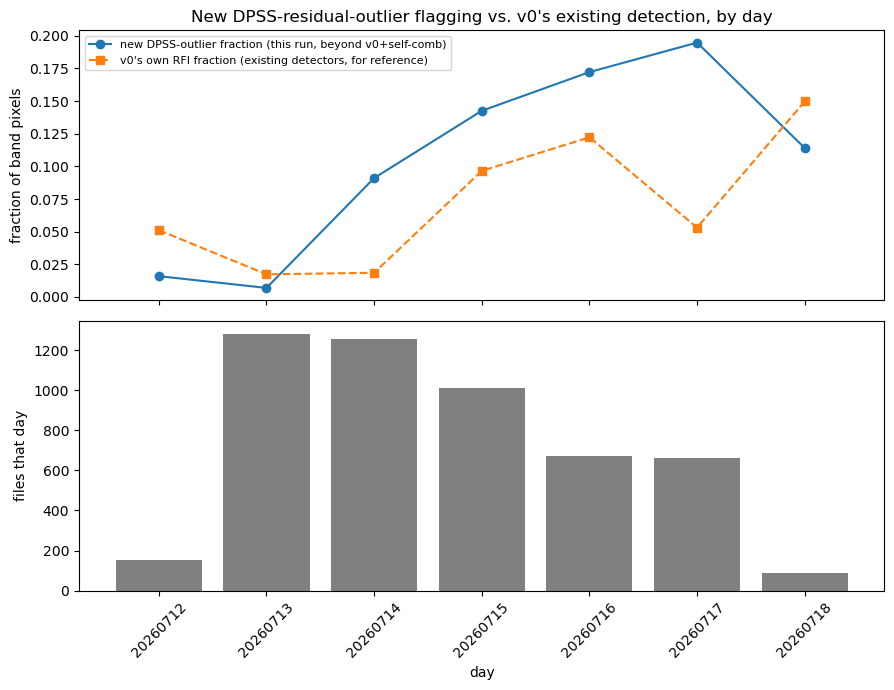

20260712: new_dpss_outlier=1.59%  v0_rfi=5.11%  n_files=155
20260713: new_dpss_outlier=0.69%  v0_rfi=1.73%  n_files=1283
20260714: new_dpss_outlier=9.10%  v0_rfi=1.85%  n_files=1255
20260715: new_dpss_outlier=14.25%  v0_rfi=9.65%  n_files=1009
20260716: new_dpss_outlier=17.22%  v0_rfi=12.22%  n_files=670
20260717: new_dpss_outlier=19.48%  v0_rfi=5.31%  n_files=660
20260718: new_dpss_outlier=11.40%  v0_rfi=14.97%  n_files=88


In [5]:

days = sorted(pkg_manifest["per_day_stats"].keys())
new_frac = [pkg_manifest["per_day_stats"][d]["frac_new_dpss_outlier"] for d in days]
n_files_per_day = [len(glob.glob(os.path.join(DATA_ROOT, "data", f"corr_{d}_*.h5"))) for d in days]

# v0's own RFI fraction for the same days, for comparison (averaged over both inputs)
v0_frac_by_day = []
for d in days:
    vals = [v0_summary["per_day_input"][f"{d}|{inp}"]["frac_flagged_rfi"]
             for inp in ("0", "4") if f"{d}|{inp}" in v0_summary["per_day_input"]]
    v0_frac_by_day.append(np.mean(vals) if vals else np.nan)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(days, new_frac, "o-", label="new DPSS-outlier fraction (this run, beyond v0+self-comb)")
axes[0].plot(days, v0_frac_by_day, "s--", label="v0's own RFI fraction (existing detectors, for reference)")
axes[0].set_ylabel("fraction of band pixels")
axes[0].legend(fontsize=8)
axes[0].set_title("New DPSS-residual-outlier flagging vs. v0's existing detection, by day")

axes[1].bar(days, n_files_per_day, color="gray")
axes[1].set_ylabel("files that day")
axes[1].set_xlabel("day")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for d, f, v, n in zip(days, new_frac, v0_frac_by_day, n_files_per_day):
    print(f"{d}: new_dpss_outlier={100*f:.2f}%  v0_rfi={100*v:.2f}%  n_files={n}")



**Measured: a roughly monotonic rise from 0.7% (07-13) to ~19.5%
(07-17), not tracking file-count-per-day** (07-13/07-14 are the
longest days by file count and have the LOWEST new-outlier fractions,
07-17 is mid-sized and highest) **and not simply mirroring v0's own
RFI fraction**, which is noisier and doesn't show the same clean trend.
This means the DPSS-residual approach is catching something
systematically more prevalent later in the campaign that v0's
threshold-based detectors mostly don't.

**Candidate explanation, not confirmed here:** this session's own prior
work flagged several time-localized self-RFI events concentrated later
in the campaign window (07-16 1.25 MHz comb event, 07-17 suspected
15-min-interval LIDAR RFI) and a documented per-era escalation in
self-generated interference. A rising DPSS-outlier fraction toward
07-16/07-17/07-18 is at least consistent with that timeline. **This is
a plausible read of the shape, not a demonstrated cause** -- confirming
it would need checking whether the new-outlier pixels concentrate in
the specific frequency/time windows those known events occupy, not
done here. Flagging as the single most important open question before
treating this staged product as more than a first attempt.



## Format and promotion status (unchanged from the design, confirmed as-built)


In [6]:

print("Staged output:", STAGING)
bits = json.load(open(os.path.join(STAGING, "flag_bits.json")))
print("encoding:", bits["encoding"])
print("new bit:", [b for b in bits["bits"] if b["name"] == "dpss_residual_outlier"][0])
print()
print(f"files with B16 companion data: {pkg_manifest['n_files_with_b16_companion']}")
print(f"files without (v0 bits copied through unchanged, not an error): {pkg_manifest['n_files_without_b16_companion']}")
print(f"packaging errors: {pkg_manifest['n_errors']}")


Staged output: /mnt/data02/eigsep/marjum-2026-07/flags/v2
encoding: uint16 bitfield per (time, channel) sample (WIDENED from v0's uint8 -- bit 8 needs 2 bytes)
new bit: {'bit': 8, 'value': 256, 'name': 'dpss_residual_outlier', 'rfi': True, 'meaning': "NEW (2026-09-17): flagged by B16's DPSS smooth-band fit + per-channel-MAD residual outlier detection (REFINE_NSIG=6), analysis band only (45-235 MHz), AND NOT already flagged by v0's category bits or the campaign-wide static self-comb channel exclusion -- i.e. exactly what DPSS-fit + outlier-removal added beyond what was already known. REFINE_NSIG was left unchanged (known to over-mask relative to log-domain expectations, per Aaron's explicit instruction not to retune it for this pass -- see MEMORY.md 'B16 rev4'; Aaron has since reviewed the masks and considers them reasonable)."}

files with B16 companion data: 4125
files without (v0 bits copied through unchanged, not an error): 0
packaging errors: 0



## Decision requested

**All jobs completed cleanly across the whole arc: 0 errors in the fit
(5,120/5,120 files, including the 58-file input-3 extension), 0 errors
in packaging (4,125 files with usable B16 data, 0 without).** Runtime
came in under the pilot-based estimate (2.05h vs ~4.8h) -- **corrected
above:** real per-input coverage is 67.0% (now higher including the
input-3 files), not the originally-reported (wrong) 39.7%, and coverage
alone does not fully explain the speedup; the remainder is most likely
campaign-average refinement cost being lower than the pilot day's. A
cross-check between two independently-computed refined-pixel totals
(the fit driver's own tally vs. the packaging step's independent
re-derivation) agrees to within the expected resumed-file gap.

**Single-box scoping, then implementation, resolved same day:**
investigated before implementing -- single-box DPSS fitting already
worked for the vast majority of cases (940/1,111 genuinely-single-box
files). The one real, narrow gap (58 files with box-gnd on raw key `3`,
a different SNAP input for the same physical box during Phase A(late)/B,
confirmed by Aaron) has been implemented, re-run, and verified: `0`/`3`
never co-occur so there's no ambiguity, keys `1`/`5` deliberately
excluded (mux copies, not new coverage). **Zero files now unaccounted
for.**

**What's new and needs a look, not self-resolved here:** the
new-DPSS-outlier fraction rises roughly monotonically from 0.7% to
19.5% across the campaign week -- a real, measured, full-campaign-only
finding the pilot could not have shown. A plausible but unconfirmed
link to known late-campaign self-RFI events is noted above. **Promoted
to `flags/v2/` as the default (Aaron's direct decision, 2026-09-17);
`flags/v0/` retained in parallel, not removed.** The "why does this
fraction rise" question is still open, not resolved by this checkpoint.

**STOPPED AT REVIEW GATE — awaiting Aaron's approval.**
